In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
table {margin-left:0 !important; margin-right: auto;}
</style>
"""))

<font size="5" color="red"><b>ch3. 분류분석</b></font>

제시해주신 내용을 바탕으로 가독성과 체계성을 높여 정리한 명사구 요약입니다. 이해를 돕기 위해 일부 명확하지 않은 개념(데이터 셋 구조 및 가상 데이터 생성 목적 등)에 핵심 보충 설명을 덧붙였습니다.

---

# 1. 분류분석(Classification Analysis)

* **분류분석의 정의**
* 데이터의 독립변수(속성)를 활용한 분류 기준 수립 과정
* 타겟변수(종속변수)가 범주형(Categorical)인 지도학습 분석 기법


* **주요 활용 사례**
* 고객 등급 예측, 휴면 고객 전환 예측, 상품 구매 여부 예측, 보험 사기자 탐지 등


* **주요 라이브러리 및 설치**
* Python 대표 머신러닝 패키지 : `scikit-learn`
* 설치 명령어: `pip install scikit-learn`


## Scikit-learn 제공 데이터셋 접근 방식

### Load 계열 (패키지 내장 데이터셋)
* 패키지 설치 시 함께 제공되는 소규모 실습용 데이터셋
* 별도 네트워크 연결 없이 즉시 로드 가능
    * `load_iris()` (붓꽃 데이터), `load_boston()` (보스턴 주택 가격 데이터, *현재는 사용 권장되지 않음*)

In [2]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [3]:
# MNIST 데이터 셋 로드
(X_train, y_train), (X_test, y_test) = mnist.load_data()

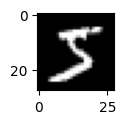

In [5]:
# 첫번째 숫자이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X_train[0], cmap='gray')
plt.show()

### Fetch 계열 (외부 다운로드 데이터셋)
* 데이터의 크기가 크거나 지속 업데이트가 필요한 대규모 데이터셋
* 최초 실행 시 인터넷 연결을 통한 자동 다운로드 및 캐싱
    * `fetch_covtype()` (토지 피복 유형 데이터), `fetch_20newsgroups()` (20가지 주제의 뉴스그룹 텍스트 말뭉치)

In [6]:
from sklearn.datasets import fetch_openml
import numpy as np

In [7]:
# MNIST 데이터 셋 다운로드
mnist = fetch_openml(
    name='mnist_784',
    version=1,
    as_frame=False, # 데이터 프레임 변환 여부 (기본값 : auto, False 시 넘파이 배열)
    parser='auto' # 파싱 방식 설정
)

In [10]:
X = mnist.data.astype(np.uint8)
y = mnist.target.astype(np.uint8)

In [13]:
X = X.reshape(70000, 28, 28)
X.shape, y.shape

((70000, 28, 28), (70000,))

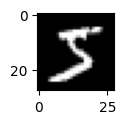

In [14]:
# 첫번째 숫자이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X[0], cmap='gray')
plt.show()

### Make 계열 (가상 데이터 생성)
* 알고리즘의 동작 원리 이해 및 성능 테스트 목적으로 생성하는 가상 데이터셋
* 데이터의 노이즈, 특성 수, 클래스 분리도 등을 사용자가 지정 가능
    *  `make_classification()` (분류 모델 실험용 가상 데이터 생성), `make_regression()` (회귀 모델 실험용 가상 데이터 생성)

In [16]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# 가상 분류 데이터 셋 생성
X_cls, y_cls = make_classification(
    n_samples=500,  # 샘플 개수
    n_features=2,  # 전체 특성 수 (2D 시각화를 위해 2개로 설정)
    n_informative=2,  # 예측에 유용한 특성 수
    n_redundant=0,  # 다른 특성의 선형 결합으로 만들어진 불필요한 특성 수
    n_classes=2,  # 클래스 개수 (이진 분류)
    class_sep=1.2,  # 클래스 간 분리도 (값이 클수록 구분이 쉬움)
    random_state=42,
    n_clusters_per_class=1 # 클래스 당 군집 수
)

In [17]:
# 데이터 구조 확인
print(X_cls.shape, y_cls.shape)

(500, 2) (500,)


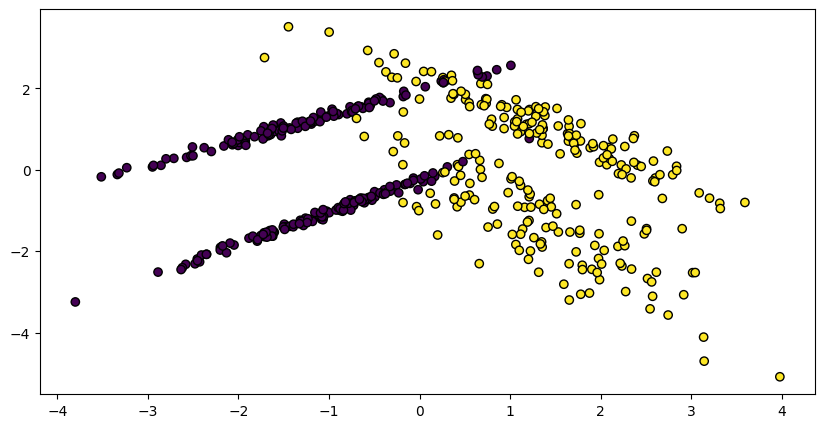

In [22]:
plt.figure(figsize=(10, 5))
plt.scatter(
    X_cls[:, 0],
    X_cls[:, 1],
    c=y_cls,
    edgecolors="k",
)
plt.show()

# 2. 분류 분석의 종류


## 2.1 확률적 모델

* **확률적 모델의 정의**
    * 입력 데이터에 대해 각 범주(Class)가 정답일 조건부 확률을 산출하는 분류 모델
    * 예측의 불확실성/확신도 측정 가능

* **`predict_proba()`**
    * 각 입력 샘플이 각 클래스에 속할 확률값(0.0 ~ 1.0)을 반환 (모든 클래스 확률의 합은 1)
    * 임계값(Threshold) 조정 및 이진/다중 분류의 정밀한 예측 판단에 활용


* **`predict_log_proba()`**
    * `predict_proba()` 결과에 자연로그(ln)를 적용한 값 반환
    * 언더플로우(Underflow, 매우 작은 확률 곱셈 시 발생하는 연산 오류) 방지 및 계산 안정성 확보 목적

## 2.1.1 확률적 생성 모델

```
QDA : sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis`
NB : sklearn.naive_bayes.MultinomialNB
```

* **베이즈 정리 기반 확률 계산 :** 데이터의 각 클래스별 특징 확률 분포를 추정한 후, 베이즈 정리를 적용하여 사후 확률 산출
    - 베이즈 정리(Bayes' theorem) : 새로운 정보나 데이터가 주어졌을 때 기존의 확률(사전 확률)을 업데이트하여 사후 확률 계산
* **데이터 효율성 :** 사전 확률 및 우도(Likelihood) 분포를 활용하여 소량의 데이터셋 환경에서도 안정적인 학습 및 예측 수행
    - 우도(Likelihood) 분포 : 특정 파라미터가 주어졌을 때 관측된 데이터가 나타날 확률 density/mass를 파라미터에 대한 함수로 표현한 분포

### QDA (Quadratic Discriminant Analysis)
* 변수 간 비선형 관계 포착에 유용하며, 데이터 수가 충분하고 클래스 간 변동성이 다를 때 효과적
* 각 클래스별 독립변수 X의 분포가 정규분포를 따른다고 가정
* 클래스마다 서로 다른 공분산 행렬(Covariance Matrix)을 허용하여 곡선 형태의 이차(Quadratic) 경계면 형성

In [43]:
# 데이터
from sklearn.datasets import make_classification
X, y = make_classification(
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=9
)

X.shape, y.shape

((100, 2), (100,))

In [46]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8,4)

In [48]:
# 난수 재배열 : 대칭 구조 생성
X[y==1] = -X[y==0]

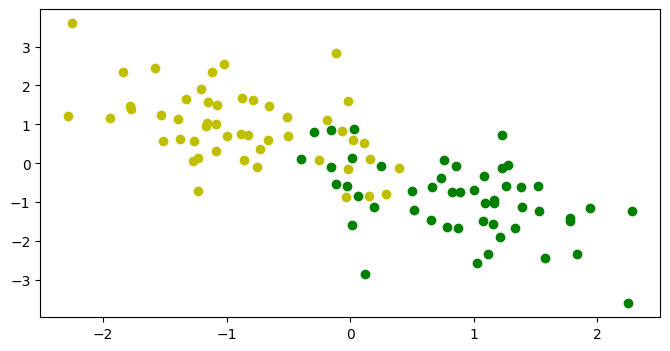

In [49]:
plt.scatter(X[y==0,0],X[y==0,1],c='y')
plt.scatter(X[y==1,0],X[y==1,1],c='g')
plt.show()

In [98]:
# QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model=QuadraticDiscriminantAnalysis()
model.fit(X, y)

x = [[0, -1]] # 입력 데이터 : 2차원
p = model.predict_proba(x)

model.predict(x)

array([1])

In [75]:
# 모델의 클래스들
model.classes_

array([0, 1])

In [78]:
# 교차표
import pandas as pd
y_hat = model.predict(X)
pd.crosstab(y, y_hat, colnames=['예측'], rownames=['실제'])

예측,0,1
실제,,
0,44,6
1,6,44


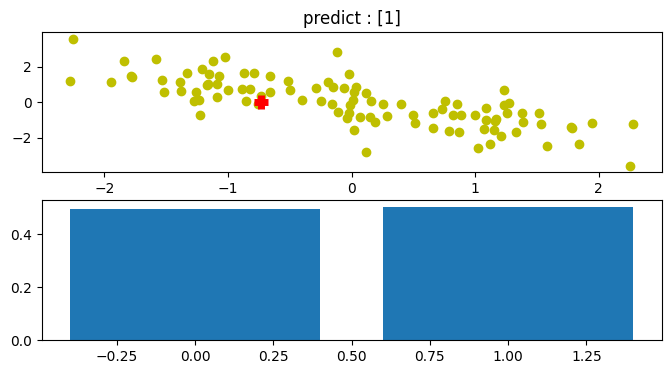

In [97]:
x = [[0.01, 0.02]]
p = model.predict_proba(x)[0]
plt.subplot(211)
plt.scatter(x=X[:,0], y=X[:,1], c='y')
plt.scatter(x=X[0][0], y=x[0][1], c='r', s=100, marker='+', lw=5)
h = model.predict(x)
plt.title(f'predict : {h}')

plt.subplot(212)
plt.bar(model.classes_, p)
plt.show()

### NB (Naive Bayesian)
- 클래스가 주어졌을 때 모든 독립변수들은 서로 통계적으로 완전 독립이라는 가정
- 강력한 독립성 가정을 통해 파라미터 수를 줄여 계산 복잡도를 크게 낮추며, 대용량 텍스트 분류(스팸 필터링, 감성 분석 등) 및 소규모 데이터셋에서 높은 성능 발휘

In [102]:
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names")

predictions = model.predict(X)

In [99]:
import seaborn as sns
iris = sns.load_dataset('iris')

X = iris.iloc[:,:-1]
y = iris.iloc[:,-1]

In [105]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X, y)

x = [[5.1, 3.5, 1.4, 0.2]]
h = model.predict(x)
p = model.predict_log_proba(x)

print('예측 :', h[0])
print(model.classes_)
print(p[0])

예측 : setosa
['setosa' 'versicolor' 'virginica']
[-0.28502512 -1.82678902 -2.44098368]


<BarContainer object of 3 artists>

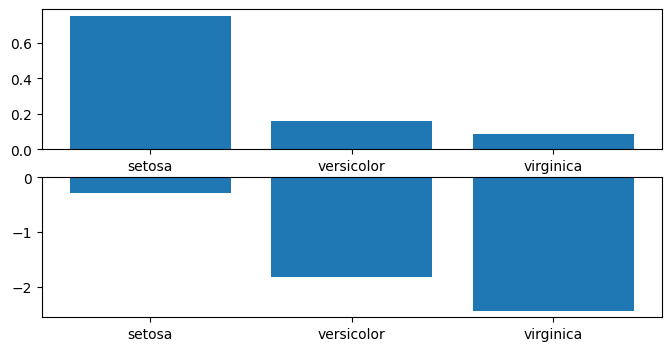

In [108]:
plt.subplot(211)
plt.bar(model.classes_, model.predict_proba(x)[0])

plt.subplot(212)
plt.bar(model.classes_, model.predict_log_proba(x)[0])

In [109]:
model.score(X, y)

0.9533333333333334

## 2.1.2 확률적 판별 모델

```
LR : sklearn.linear_model.LogisticRegression
DT : sklearn.tree.DecisionTreeClassifier
```

* **조건부 확률 분포 직접 추정 :** 데이터의 분포를 별도로 모델링하지 않고, 입력 특징에 대한 클래스 확률을 직접 추정
* **우수한 예측 성능 및 높은 해석 가능성 :** 결합 분포 추정에 따른 계산 복잡도를 줄여 실전 예측 성능이 뛰어나며, 계수(Weight) 분석을 통한 직관적 해석 용이

### 로지스틱 회귀 (Logistic Regression)
-  종속변수가 범주형/이진(0 또는 1, Success/Failure)일 경우

In [110]:
# 가상 데이터 셋 생성
X, y = make_classification(
    n_samples=100,
    n_features=1,
    n_redundant=0,
    n_informative=1,
    n_clusters_per_class=1,
    random_state=1
)

In [111]:
np.c_[X,y][:3]

array([[-1.65902848,  0.        ],
       [-0.64202884,  0.        ],
       [-1.53918976,  0.        ]])

In [112]:
# 모델 생성
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X, y)

In [113]:
# 모델 예측용 데이터
x_data = np.linspace(-3, 3, 100) # 1차원 데이터
x_data = np.expand_dims(x_data, axis=1) # 축 확장 (1차원 → 2차원)

In [119]:
prob = model.predict_proba(x_data)
prob[:3]

array([[9.99986168e-01, 1.38320570e-05],
       [9.99982885e-01, 1.71146738e-05],
       [9.99978824e-01, 2.11763030e-05]])

In [120]:
prob0 = prob[:, 0] # 0일 확률
prob1 = prob[:, 1] # 1일 확률

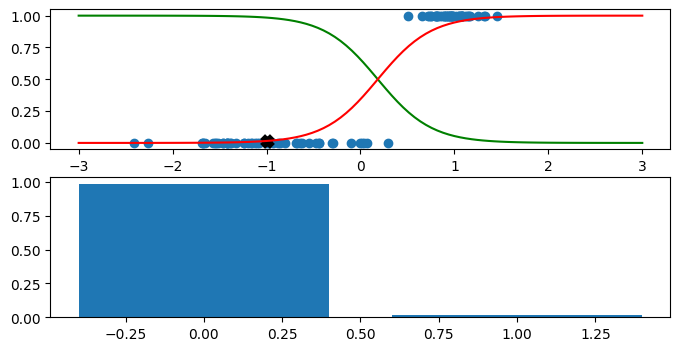

In [125]:
plt.subplot(211)
plt.scatter(X, y)
plt.plot(x_data, prob0, c='g')
plt.plot(x_data, prob1, c='r')
x = [[-1]]
prob_x = model.predict_proba(x)[0]
plt.scatter(x[0], prob_x[1], marker='x', c='k', lw=5, s=50)

plt.subplot(212)
plt.bar(model.classes_, prob_x)
plt.show()

### 의사 결정 나무 (Decision Tree)
- 여러 개의 독립변수 조건을 순차적으로 적용하여 독립변수 전체 공간을 상호 배타적인 영역으로 분할하는 분류 모형
- 트리 구조 형태 : Root Node(뿌리 노드)에서 시작하여 Decision Node(중간 노드)의 조건 판단을 거쳐 Leaf Node(최종 끝 노드)에서 예측 클래스를 결정
    * 우수한 직관성 및 해석력 : 시각화가 쉬우며, 데이터 스케일링(정규화/표준화) 등의 전처리 영향이 적음
    * 과적합(Overfitting) 위험 : 트리가 깊어질수록 과적합 가능성이 높아져 가지치기(Pruning) 및 하이퍼파라미터(`max_depth` 등) 조절 필수

In [133]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data[:, 2:]
y = data.target
feature_names = [name[:5] for name in data.feature_names[2:]]

In [134]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
criterion='entropy',  # 분할 기준 : 정보 이득이 높은 방향으로 가지를 치도록 '엔트로피' 지표 사용
    max_depth=1, # 나무의 최대 깊이 : 1단계만 가지치기 진행
    random_state=0
)

dt_model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)

In [136]:
x_data = [[1.5, 0.2]]
dt_model.predict(x_data)

array([0])

In [140]:
dt_model.predict_proba(x_data)[0]

array([1., 0., 0.])

In [141]:
dt_model.score(X, y)

0.6666666666666666

In [142]:
dt_model5 = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=0
)
dt_model5.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [143]:
dt_model5.score(X, y)

0.9933333333333333

In [144]:
dt_model5.predict(x_data)

array([0])

In [145]:
dt_model5.predict_proba(x_data)[0]

array([1., 0., 0.])

## 2.2 판별 함수 모델 (Discriminative Function Models)
```
Perceptron : sklearn.linear_model.Perceptron
SVM : sklearn.svm.SVC
NN : sklearn.neural_network.MLPClassifier
```
* **판별 함수 모델의 정의**
    * 데이터를 클래스별 영역으로 분할하는 **결정 경계(Decision Boundary)** 탐색 모델
    * 경계면으로부터 대상 데이터까지의 위치/거리를 계산하는 판별 함수 활용
    * 확률 산출 절차 없이 데이터의 속성을 경계면에 직접 Mapping하여 속한 클래스를 판단

* `decision_function()`
    * 입력 샘플과 결정 경계면 사이의 **signed distance(부호가 있는 거리)** 또는 판별 점수 반환
    * 서포트 벡터 머신(SVM), 선형 판별 분석(LDA) 등 대표적 판별 모델에서 활용